In [1]:
import sys, os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from dataset.mnist import load_mnist
from simple_conv_net import SimpleConvNet
from common.trainer import Trainer

In [4]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False)

In [5]:
max_epochs = 20

In [6]:
network = SimpleConvNet(input_dim=(1, 28, 28),
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01
                        )

In [7]:
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer = 'Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)

In [8]:
trainer.train()

train loss:2.2991588916893613
=== epoch:1, train acc:0.185, test acc:0.175 ===
train loss:2.2945087929298804
train loss:2.290139778898121
train loss:2.2891301688937644
train loss:2.273399190175036
train loss:2.2540824497485756
train loss:2.234811649421661
train loss:2.2149876760593328
train loss:2.2143654646462263
train loss:2.1779305835455527
train loss:2.1329994163740253
train loss:2.117054867307216
train loss:2.104767583330616
train loss:2.0387743175601654
train loss:1.9525683771681863
train loss:1.9333864908916039
train loss:1.8937775316292957
train loss:1.752130887098619
train loss:1.7610085403334552
train loss:1.5104837270876
train loss:1.6055062739412063
train loss:1.4467677961530618
train loss:1.2916105488419738
train loss:1.2127616770236205
train loss:1.130868499752877
train loss:1.249995990970927
train loss:1.1567398806250913
train loss:1.0979883530834031
train loss:1.1053220001186674
train loss:0.8738015982796972
train loss:1.035371124472202
train loss:0.9276134982176693
tra

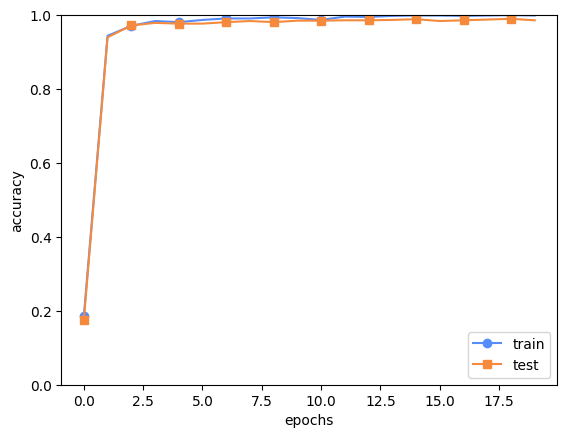

In [9]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

In [10]:
def filter_show(filters, nx=8, margin=3, scale=10):
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()

In [11]:
network.save_params("params.pkl")

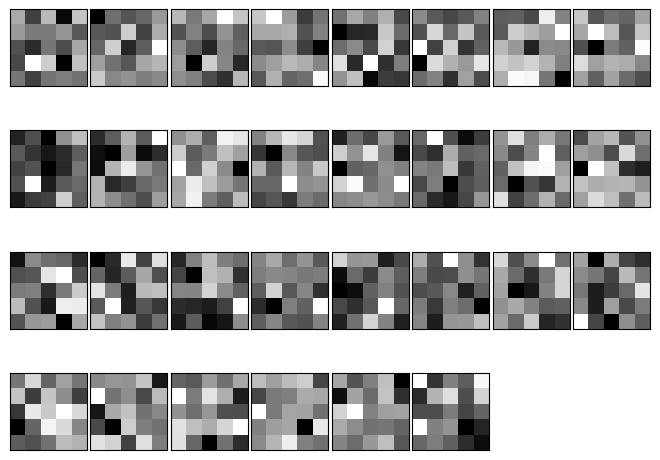

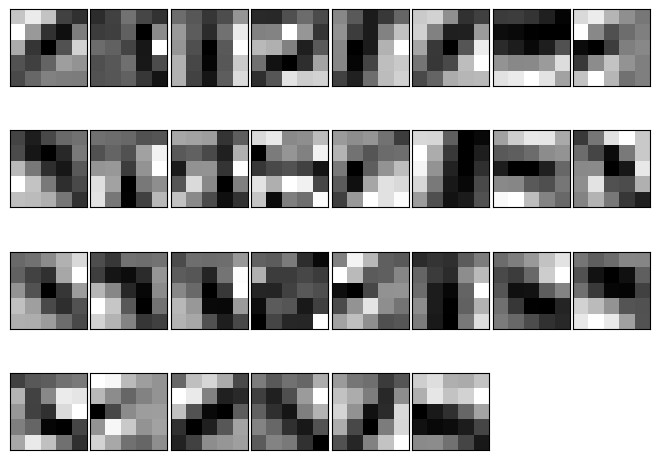

In [12]:
network = SimpleConvNet()
# 무작위(랜덤) 초기화 후의 가중치
filter_show(network.params['W1'])

# 학습된 가중치
network.load_params("params.pkl")
filter_show(network.params['W1'])